# Bernoulli k-Sample Sequential E-Test                                       
                                                                           
## Demonstrates anytime-valid k-sample homogeneity testing for Bernoulli data:
- 2-sample A/B testing (unrestricted alternative)                          
- Multi-arm testing (k=3, k=5)                                            
- Effect-size restricted alternatives (additive, log odds ratio)           
- Simple (fixed theta) alternative                                         
- Betting strategy comparison (ALL_IN, CONSERVATIVE, EMPIRICALLY_ADAPTIVE) 
- Optional stopping: stop as soon as evidence is sufficient                
- Real-world: e-commerce checkout A/B/C test (k=3, moderate rates)         
- Real-world: ad auction bid strategy CTR comparison (k=4, low rates)      
                                                                           
The construction produces exact e-variables under optional stopping using   
the RIPr (Reverse Information Projection) framework.                       
                                                                           
References:                                                                
    Turner, Ly & Grunwald (2022). Generic E-Variables for Exact Sequential 
    k-Sample Tests that allow for Optional Stopping.                       
    - Proposition 2: Unrestricted alternative (closed-form Beta posterior)  
    - Appendix S1: Effect-size restricted alternative (grid-based)         
    - Section 5: REGROW-optimal gamma ~ 0.18 

In [1]:
import numpy as np                                                         
import matplotlib.pyplot as plt                                            
import pandas as pd                                                        
                                                                           
from expectation.ksample.config import (                                   
    KSampleConfig,                                                         
    KSampleAlternativeType,                                                
    DivergenceType,                                                        
)                                                                          
from expectation.ksample.ksample_test import KSampleSequentialTest         
from expectation.modules.hypothesistesting import BettingStrategy   

from expectation.utils.helper_functions import (
    evidence_palette, apply_evidence_layout, plot_ksample_dashboard,
)
_EV = evidence_palette() 

# 1. Basic 2-Sample A/B Test (Unrestricted Alternative)

Test H0: theta_A = theta_B vs H1: theta_A != theta_B.

We simulate two conversion funnels with different true rates and stream
observations block by block. The test uses a Beta(0.18, 0.18) prior
(REGROW-optimal, Section 5) and the all-in betting strategy.

In [2]:
np.random.seed(42)

theta_control = 0.10      # 10% baseline
theta_treatment = 0.15    # 15% treatment (5pp lift)
block_size = 50           # users per group per batch
n_blocks = 200

config = KSampleConfig(
    k=2,
    significance_level=0.05,
    gamma=0.18,                                # REGROW-optimal (Section 5)
    betting_strategy=BettingStrategy.ALL_IN,
    alternative_type=KSampleAlternativeType.UNRESTRICTED,
)

test = KSampleSequentialTest(config)

for block in range(n_blocks):
    control = np.random.binomial(1, theta_control, size=block_size)
    treatment = np.random.binomial(1, theta_treatment, size=block_size)

    result = test.update({0: control, 1: treatment})

    if result.reject_null:
        print(f"Rejected H0 at block {block + 1} "
              f"(n={result.group_counts[0] + result.group_counts[1]} total observations)")
        print(f"  E-process value: {result.e_process_value:.2f}")
        print(f"  Anytime-valid p-value: {result.p_value:.2e}")
        print(f"  Group means: control={result.group_means[0]:.3f}, "
              f"treatment={result.group_means[1]:.3f}")
        break
else:
    print(f"No rejection after {n_blocks} blocks")
    print(f"  Final e-process: {result.e_process_value:.4f}")

Rejected H0 at block 17 (n=1700 total observations)
  E-process value: 20.59
  Anytime-valid p-value: 4.86e-02
  Group means: control=0.108, treatment=0.156


In [3]:
df = test.get_history_df()

fig = plot_ksample_dashboard(
    df, alpha=config.significance_level,
    group_labels=['Control', 'Treatment'],
    true_values={0: theta_control, 1: theta_treatment},
    title='2-sample A/B Test')

fig.show()

# 2. Multi-Arm Trial (k=3)

Test H0: theta_1 = theta_2 = theta_3 with three treatment arms.
Two arms have the same rate (0.10), one arm has an elevated rate (0.20).
The test should detect this heterogeneity.

Rejected H0 at block 5
  E-process: 42.37
  Group means: {0: 0.07333333333333333, 1: 0.12666666666666668, 2: 0.2}


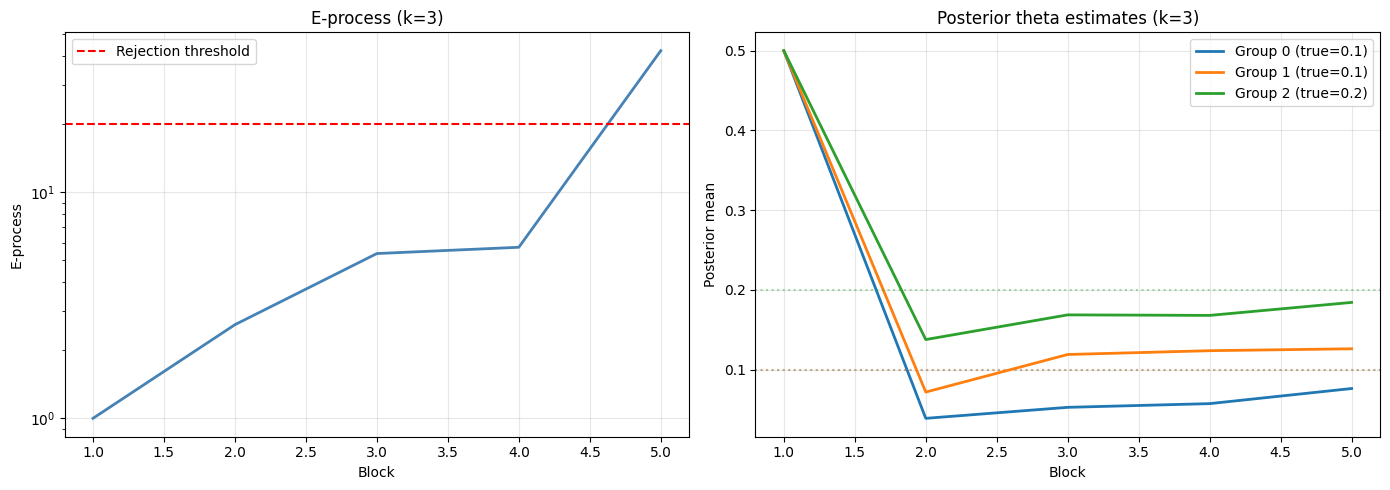

In [11]:
np.random.seed(123)

true_rates = {0: 0.10, 1: 0.10, 2: 0.20}
block_size = 30
n_blocks = 300

config_k3 = KSampleConfig(k=3, significance_level=0.05, gamma=0.18)
test_k3 = KSampleSequentialTest(config_k3)

for block in range(n_blocks):
    group_data = {
        g: np.random.binomial(1, true_rates[g], size=block_size)
        for g in range(3)
    }
    result = test_k3.update(group_data)

    if result.reject_null:
        print(f"Rejected H0 at block {block + 1}")
        print(f"  E-process: {result.e_process_value:.2f}")
        print(f"  Group means: {result.group_means}")
        break
else:
    print(f"No rejection after {n_blocks} blocks")

# Plot
df_k3 = test_k3.get_history_df()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_k3['step'], df_k3['e_process_value'], linewidth=2, color='steelblue')
ax1.axhline(1 / 0.05, color='red', linestyle='--', label='Rejection threshold')
ax1.set_xlabel('Block')
ax1.set_ylabel('E-process')
ax1.set_title('E-process (k=3)')
ax1.set_yscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

for g in range(3):
    ax2.plot(df_k3['step'], df_k3[f'theta_{g}'],
             label=f'Group {g} (true={true_rates[g]})', linewidth=2)
    ax2.axhline(true_rates[g], color=f'C{g}', linestyle=':', alpha=0.4)
ax2.set_xlabel('Block')
ax2.set_ylabel('Posterior mean')
ax2.set_title('Posterior theta estimates (k=3)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Effect-Size Restricted Alternative (Appendix S1)

When you know the minimum effect size you want to detect, the restricted
alternative focuses power on that region. This uses a grid-based discretized
posterior (Appendix S1), only available for k=2.

We compare:
- **Unrestricted**: detects any difference
- **Restricted (additive, delta=0.05)**: optimized for >= 5pp lift

When the true effect matches delta, the restricted test should be more powerful.

True effect: theta_a=0.1, theta_b=0.15000000000000002 (delta=0.05)
Unrestricted: rejected at block 11
Restricted:   rejected at block 3


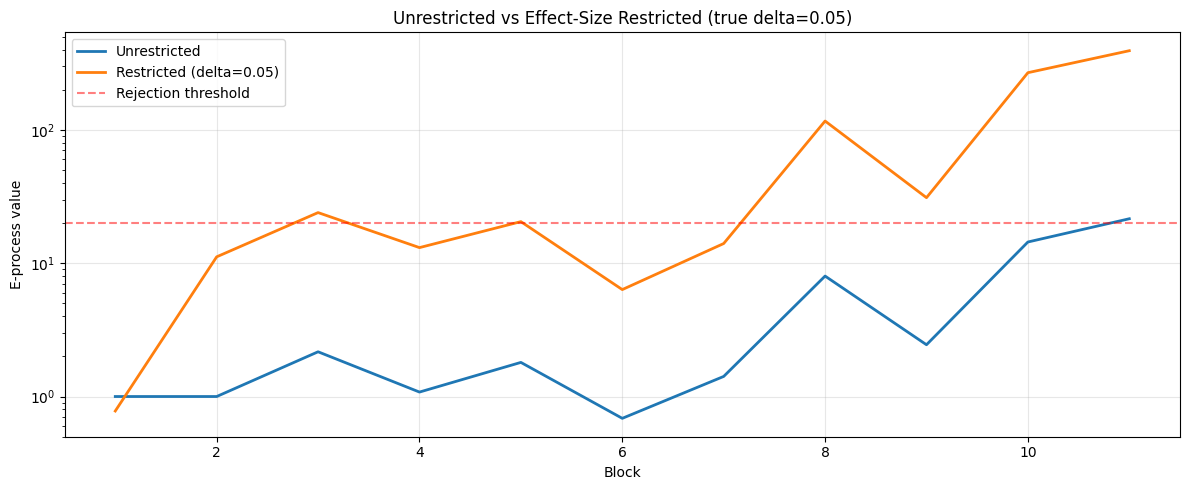

In [ ]:
np.random.seed(777)

theta_a = 0.10
delta = 0.05
theta_b = theta_a + delta  # true effect exactly matches delta
block_size = 100
n_blocks = 500

# Unrestricted test
config_unr = KSampleConfig(k=2, significance_level=0.05, gamma=0.18)
test_unr = KSampleSequentialTest(config_unr)

# Effect-size restricted test (additive)
config_res = KSampleConfig(
    k=2,
    significance_level=0.05,
    gamma=0.18,
    alternative_type=KSampleAlternativeType.EFFECT_SIZE,
    divergence_type=DivergenceType.ADDITIVE,
    min_effect_size=delta,
    grid_precision=0.01,
)
test_res = KSampleSequentialTest(config_res)

stop_unr, stop_res = None, None

for block in range(n_blocks):
    data_a = np.random.binomial(1, theta_a, size=block_size)
    data_b = np.random.binomial(1, theta_b, size=block_size)

    r_unr = test_unr.update({0: data_a, 1: data_b})
    r_res = test_res.update({0: data_a, 1: data_b})

    if r_unr.reject_null and stop_unr is None:
        stop_unr = block + 1
    if r_res.reject_null and stop_res is None:
        stop_res = block + 1

    if stop_unr and stop_res:
        break

print(f"True effect: theta_a={theta_a}, theta_b={theta_b} (delta={delta})")
print(f"Unrestricted: {'rejected at block ' + str(stop_unr) if stop_unr else 'not rejected'}")
print(f"Restricted:   {'rejected at block ' + str(stop_res) if stop_res else 'not rejected'}")

df_unr = test_unr.get_history_df()
df_res = test_res.get_history_df()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_unr['step'], df_unr['e_process_value'], label='Unrestricted', linewidth=2)
ax.plot(df_res['step'], df_res['e_process_value'], label=f'Restricted (delta={delta})', linewidth=2)
ax.axhline(1 / 0.05, color='red', linestyle='--', alpha=0.5, label='Rejection threshold')
ax.set_xlabel('Block')
ax.set_ylabel('E-process value')
ax.set_title(f'Unrestricted vs Effect-Size Restricted (true delta={delta})')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Log Odds Ratio Restriction

Instead of additive difference, restrict to log(OR) >= delta.
Useful when the effect is better expressed on the odds scale
(e.g., clinical trials with baseline rates near 0 or 1).

In [13]:
np.random.seed(999)

theta_a = 0.20
delta_lor = 0.5  # log odds ratio

# Derive theta_b from constraint: log(OR) = delta
odds_a = theta_a / (1 - theta_a)
theta_b = (odds_a * np.exp(delta_lor)) / (1 + odds_a * np.exp(delta_lor))
print(f"theta_a={theta_a}, theta_b={theta_b:.4f} (log OR = {delta_lor})")
print(f"Actual odds ratio: {(theta_b/(1-theta_b)) / (theta_a/(1-theta_a)):.4f}")

config_lor = KSampleConfig(
    k=2,
    significance_level=0.05,
    gamma=0.18,
    alternative_type=KSampleAlternativeType.EFFECT_SIZE,
    divergence_type=DivergenceType.LOG_ODDS_RATIO,
    min_effect_size=delta_lor,
)
test_lor = KSampleSequentialTest(config_lor)

for block in range(300):
    data_a = np.random.binomial(1, theta_a, size=50)
    data_b = np.random.binomial(1, theta_b, size=50)
    result = test_lor.update({0: data_a, 1: data_b})

    if result.reject_null:
        print(f"Rejected at block {block + 1}, e-process={result.e_process_value:.2f}")
        break
else:
    print(f"Not rejected after 300 blocks, e-process={result.e_process_value:.4f}")

theta_a=0.2, theta_b=0.2919 (log OR = 0.5)
Actual odds ratio: 1.6487
Rejected at block 4, e-process=38.16


# 5. Betting Strategy Comparison

Compare three betting strategies for temporal e-process combination
(Ramdas & Wang 2025, Chapter 7):

- **ALL_IN** (Prop 7.20): lambda=1. Most aggressive -> e-process = product of e-values.
- **CONSERVATIVE** (Def 7.21i): fixed lambda=0.5. More robust.
- **EMPIRICALLY_ADAPTIVE** (Def 7.21iii): ONS-based adaptive lambda.

All strategies produce valid e-processes (type-I error controlled at alpha),
but differ in power and robustness.

ALL_IN                    | stopped=   56 | final e-process=30898363.55
CONSERVATIVE (0.5)        | stopped=   61 | final e-process=314543.68
ADAPTIVE                  | stopped=  130 | final e-process=245.23


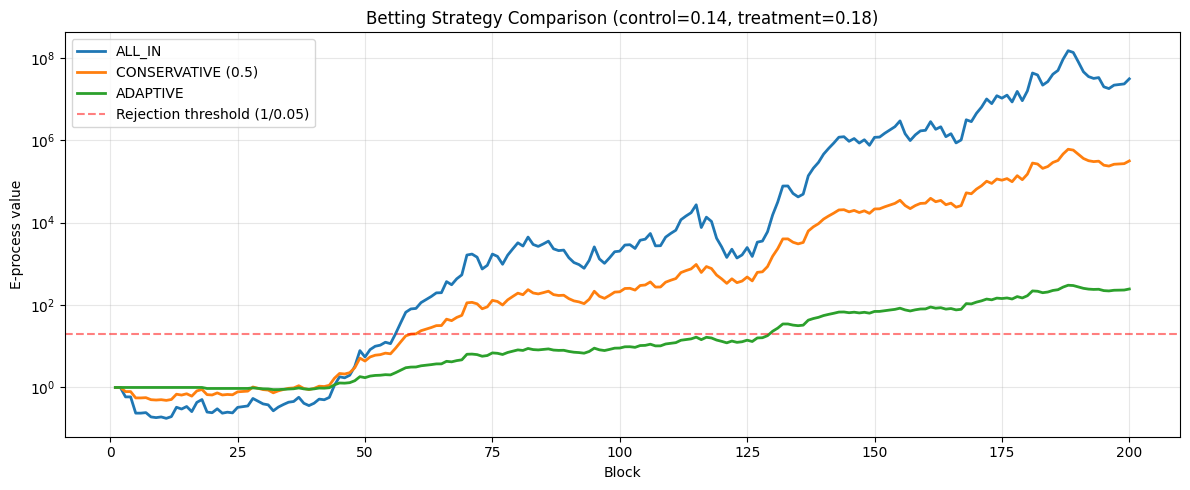

In [14]:
strategies = {
    "ALL_IN": BettingStrategy.ALL_IN,
    "CONSERVATIVE (0.5)": BettingStrategy.CONSERVATIVE,
    "ADAPTIVE": BettingStrategy.EMPIRICALLY_ADAPTIVE,
}

theta_ctrl, theta_trt = 0.14, 0.18
block_size = 40
n_blocks = 200

strategy_results = {}

for name, strategy in strategies.items():
    np.random.seed(42)  # same data for fair comparison
    cfg = KSampleConfig(
        k=2, significance_level=0.05, gamma=0.18,
        betting_strategy=strategy, conservative_lambda=0.5,
    )
    t = KSampleSequentialTest(cfg)

    stop_block = None
    for b in range(n_blocks):
        data_a = np.random.binomial(1, theta_ctrl, size=block_size)
        data_b = np.random.binomial(1, theta_trt, size=block_size)
        r = t.update({0: data_a, 1: data_b})
        if r.reject_null and stop_block is None:
            stop_block = b + 1

    strategy_results[name] = t.get_history_df()
    final_ep = t.e_process.process_values[-1]
    print(f"{name:25s} | stopped={stop_block or 'N/A':>5} | final e-process={final_ep:.2f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
for name, df_s in strategy_results.items():
    ax.plot(df_s['step'], df_s['e_process_value'], label=name, linewidth=2)
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='Rejection threshold (1/0.05)')
ax.set_xlabel('Block')
ax.set_ylabel('E-process value')
ax.set_title(f'Betting Strategy Comparison (control={theta_ctrl}, treatment={theta_trt})')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Type-I Error Validity Under H0

Under H0 (all groups have the same true rate), the test should reject at most
alpha fraction of the time regardless of when we stop. This is the key
anytime-validity guarantee from Ville's inequality.

We run 2000 simulations under H0 with optional stopping and verify the
empirical rejection rate is controlled.

In [15]:
np.random.seed(2024)

alpha = 0.05
theta_0 = 0.30  # same rate for both groups
n_simulations = 2000
max_blocks = 200
block_size = 20

rejections = 0
final_e_processes = []

for sim in range(n_simulations):
    cfg = KSampleConfig(k=2, significance_level=alpha, gamma=0.18)
    t = KSampleSequentialTest(cfg)

    rejected = False
    for b in range(max_blocks):
        data_a = np.random.binomial(1, theta_0, size=block_size)
        data_b = np.random.binomial(1, theta_0, size=block_size)
        r = t.update({0: data_a, 1: data_b})
        if r.reject_null:
            rejected = True
            break

    if rejected:
        rejections += 1
    final_e_processes.append(t.e_process.process_values[-1])

rejection_rate = rejections / n_simulations
se = np.sqrt(rejection_rate * (1 - rejection_rate) / n_simulations)

print(f"Type-I error simulation (H0: both groups at theta={theta_0})")
print(f"  Simulations:    {n_simulations}")
print(f"  Max blocks:     {max_blocks}")
print(f"  Rejections:     {rejections}")
print(f"  Rejection rate: {rejection_rate:.4f} +/- {1.96*se:.4f}")
print(f"  Nominal alpha:  {alpha}")
print(f"  Valid:          {rejection_rate <= alpha + 3*se}")
print(f"  Median final e-process: {np.median(final_e_processes):.4f}")

Type-I error simulation (H0: both groups at theta=0.3)
  Simulations:    2000
  Max blocks:     200
  Rejections:     59
  Rejection rate: 0.0295 +/- 0.0074
  Nominal alpha:  0.05
  Valid:          True
  Median final e-process: 0.0683


# 7. Simple Alternative (fixed Theta)

When you have a specific alternative in mind (e.g., from a pilot study),
you can use a simple alternative with fixed theta values (Eq. 3.2).
This avoids posterior computation entirely, the e-value is the
likelihood ratio at the specified alternative.

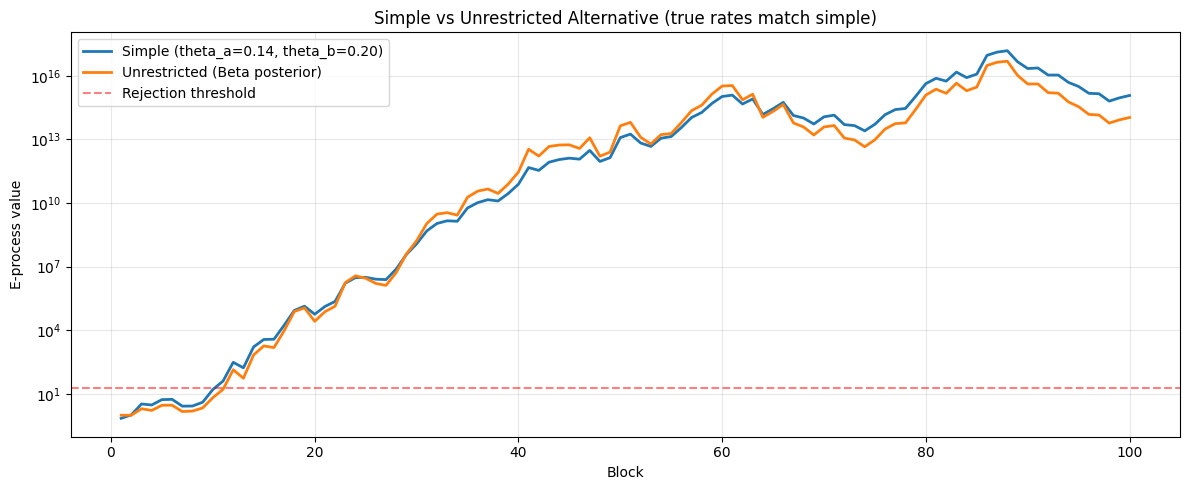

Simple final e-process:       1172072913358737.25
Unrestricted final e-process: 107213705228052.27


In [16]:
np.random.seed(55)

# Prior belief: control=0.10, treatment=0.20
config_simple = KSampleConfig(
    k=2,
    significance_level=0.05,
    alternative_type=KSampleAlternativeType.SIMPLE,
    simple_theta={0: 0.14, 1: 0.20},
)

# Compare with unrestricted on the same data
config_unr = KSampleConfig(k=2, significance_level=0.05, gamma=0.18)

test_simple = KSampleSequentialTest(config_simple)
test_unrestricted = KSampleSequentialTest(config_unr)

# True rates match the simple alternative exactly
for block in range(100):
    data_a = np.random.binomial(1, 0.14, size=50)
    data_b = np.random.binomial(1, 0.20, size=50)
    test_simple.update({0: data_a, 1: data_b})
    test_unrestricted.update({0: data_a, 1: data_b})

df_sim = test_simple.get_history_df()
df_unr = test_unrestricted.get_history_df()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_sim['step'], df_sim['e_process_value'],
        label='Simple (theta_a=0.14, theta_b=0.20)', linewidth=2)
ax.plot(df_unr['step'], df_unr['e_process_value'],
        label='Unrestricted (Beta posterior)', linewidth=2)
ax.axhline(20, color='red', linestyle='--', alpha=0.5, label='Rejection threshold')
ax.set_xlabel('Block')
ax.set_ylabel('E-process value')
ax.set_title('Simple vs Unrestricted Alternative (true rates match simple)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Simple final e-process:       {test_simple.e_process.process_values[-1]:.2f}")
print(f"Unrestricted final e-process: {test_unrestricted.e_process.process_values[-1]:.2f}")

# 8. Scaling to Many Groups (k=5)

The test generalizes to any k >= 2. Here we run a 5-arm trial where
one arm is different from the rest.

k=5: Rejected H0 at block 2
  E-process: 22.14
  Group 0: mean=0.175, theta_hat=0.156, true=0.15
  Group 1: mean=0.150, theta_hat=0.107, true=0.15
  Group 2: mean=0.200, theta_hat=0.254, true=0.15
  Group 3: mean=0.050, theta_hat=0.058, true=0.15
  Group 4: mean=0.375, theta_hat=0.304, true=0.3


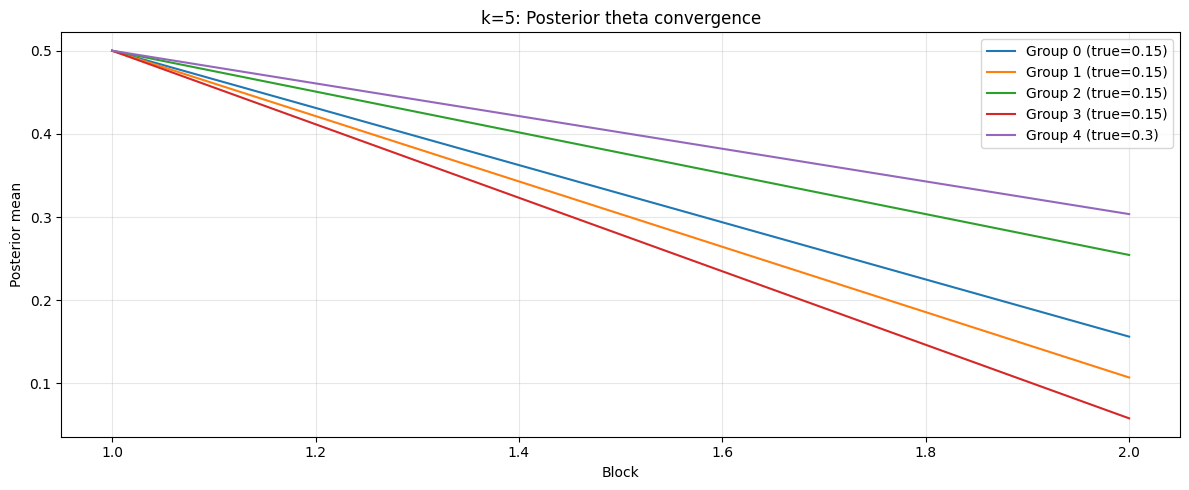

In [17]:
np.random.seed(42)

k = 5
true_rates_k5 = {0: 0.15, 1: 0.15, 2: 0.15, 3: 0.15, 4: 0.30}

config_k5 = KSampleConfig(k=k, significance_level=0.05, gamma=0.18)
test_k5 = KSampleSequentialTest(config_k5)

for block in range(500):
    group_data = {
        g: np.random.binomial(1, true_rates_k5[g], size=20)
        for g in range(k)
    }
    result = test_k5.update(group_data)
    if result.reject_null:
        print(f"k=5: Rejected H0 at block {block + 1}")
        print(f"  E-process: {result.e_process_value:.2f}")
        for g in range(k):
            print(f"  Group {g}: mean={result.group_means[g]:.3f}, "
                  f"theta_hat={result.theta_estimates[g]:.3f}, "
                  f"true={true_rates_k5[g]}")
        break
else:
    print(f"Not rejected after 500 blocks")

# Plot posterior convergence
df_k5 = test_k5.get_history_df()

fig, ax = plt.subplots(figsize=(12, 5))
for g in range(k):
    ax.plot(df_k5['step'], df_k5[f'theta_{g}'],
            label=f'Group {g} (true={true_rates_k5[g]})', linewidth=1.5)
ax.set_xlabel('Block')
ax.set_ylabel('Posterior mean')
ax.set_title('k=5: Posterior theta convergence')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Real World: E-Commerce Checkout A/B/C Test

**Scenario:** A mid-market DTC e-commerce brand (think Allbirds, Glossier) runs
an A/B/C test on three checkout page variants to improve checkout completion rate, the fraction of users who land on the checkout page and complete the purchase.

- **Group 0 (Control):** Current single-page checkout with standard card form
- **Group 1 (Express Payment):** Apple Pay / Google Pay buttons above the card form
- **Group 2 (Two-Step Checkout):** Redesigned two-step flow (shipping, then payment)

The binary outcome: did the user complete the purchase? (1 = yes, 0 = abandoned)

**Why sequential testing matters here:**
- Every day the inferior variant is shown costs real revenue. At $50 AOV with
  ~2,300 users/day per group, a 3pp lift is worth ~$3,450/day in lost conversions.
- The team wants to peek at results continuously without inflating type-I error.
- Engineering cost of maintaining 3 code paths means faster decisions save effort.

**Realistic parameters:** Checkout completion rates are 40-55% for users who
reach the checkout page. A 3pp absolute lift (6.7% relative) from express payment
is realistic. The two-step redesign is a lateral move, no real lift.

In [ ]:
np.random.seed(2025)

# True checkout completion rates
true_rates_checkout = {
    0: 0.45,   # Control: single-page checkout
    1: 0.48,   # Express payment: +3pp lift (Apple Pay / Google Pay)
    2: 0.45,   # Two-step checkout: lateral move, no real lift
}

# ~7,000 daily checkout visitors split 3 ways -> ~2,300/group/day
# A block of 200 per group represents roughly 2-3 hours of traffic
block_size_checkout = 200
n_blocks_checkout = 150  # up to ~2 weeks of data

config_checkout = KSampleConfig(
    k=3,
    significance_level=0.05,
    gamma=0.18,
    betting_strategy=BettingStrategy.ALL_IN,
    alternative_type=KSampleAlternativeType.UNRESTRICTED,
)

test_checkout = KSampleSequentialTest(config_checkout)

stop_block_checkout = None
for block in range(n_blocks_checkout):
    group_data = {
        g: np.random.binomial(1, true_rates_checkout[g], size=block_size_checkout)
        for g in range(3)
    }
    result = test_checkout.update(group_data)

    if result.reject_null and stop_block_checkout is None:
        stop_block_checkout = block + 1

# Report
if stop_block_checkout:
    users_at_stop = stop_block_checkout * block_size_checkout * 3
    days_at_stop = stop_block_checkout / (2300 / block_size_checkout * 3)  # ~11.5 blocks/day
    print(f"Rejected H0 at block {stop_block_checkout}")
    print(f"  Total users tested: {users_at_stop:,}")
    print(f"  Approximate days: {days_at_stop:.1f}")
    print(f"  Revenue saved by early stopping: ~${(150 - stop_block_checkout) * 3450 / 11.5:.0f}")
else:
    print(f"No rejection after {n_blocks_checkout} blocks")

summary = test_checkout.get_summary()
print(f"\nGroup means: {summary['group_means']}")
print(f"Final e-process: {summary['current_e_process']:.2f}")

df_checkout = test_checkout.get_history_df()

fig = plot_ksample_dashboard(
    df_checkout, alpha=0.05,
    group_labels=['Control (standard)', 'Express Payment', 'Two-Step Checkout'],
    true_values=true_rates_checkout,
    group_colors=[_EV['teal'], _EV['gold'], _EV['violet']],
    stop_block=stop_block_checkout,
    title='E-Commerce Checkout A/B/C Test', width=1050)
fig.show()

print("\nInterpretation:")
print("  The express payment variant (Group 1) produces a real 3pp lift.")
print("  The two-step redesign (Group 2) is indistinguishable from control.")
print("  The sequential test detects the heterogeneity and stops early,")
print("  saving weeks of traffic that would have been wasted on inferior variants.")

Rejected H0 at block 48
  Total users tested: 28,800
  Approximate days: 1.4
  Revenue saved by early stopping: ~$30600

Group means: {0: 0.44966666666666666, 1: 0.4808, 2: 0.4484}
Final e-process: 10547771002857.97



Interpretation:
  The express payment variant (Group 1) produces a real 3pp lift.
  The two-step redesign (Group 2) is indistinguishable from control.
  The sequential test detects the heterogeneity and stops early,
  saving weeks of traffic that would have been wasted on inferior variants.


# 10. Real World: Ad Auction Bid Strategy CTR Comparison

**Scenario:** A demand-side platform (DSP) participates in real-time bidding (RTB)
auctions to buy programmatic display ad inventory on behalf of advertisers. Each
auction takes ~100ms: the exchange sends a bid request, the DSP decides whether
to bid and how much, and the winner's ad is served.

The engineering team has developed **four bid optimization algorithms** and wants
to determine whether they produce different click-through rates (CTR):

- **Group 0 (Linear Bidder):** Production system. `bid = base_price * predicted_CTR`
  using logistic regression.
- **Group 1 (Optimal RTB):** Non-linear bid function from KKT conditions
  (Zhang et al. 2014). Same CTR model, different bid shaping.
- **Group 2 (RL Bidder):** DQN-based reinforcement learning agent with gradient-
  boosted CTR model. Optimizes for a composite reward (not just CTR).
- **Group 3 (Contextual Bandit):** Thompson Sampling across inventory segments.
  Same CTR model as baseline, different budget allocation.

The binary outcome: **did the user click the ad?** Different bid strategies win
different subsets of auctions, so even with similar models the realized CTR differs.

**Why sequential testing matters here:**
- Ad spend flows out every hour. An inferior algorithm wastes budget on low-CTR inventory.
- Programmatic markets are non-stationary (weekday/weekend, seasonal campaigns). The
  team needs to make decisions during stable periods, not wait through regime changes.
- Engineers peek at dashboards constantly, sequential e-tests guarantee that the
  probability of ever falsely rejecting is still controlled at alpha.
- With CTRs of ~0.35%, most observations are zeros. Signal accumulates slowly, so the
  test must be able to continue indefinitely without penalty if evidence is insufficient.

**Realistic parameters:** Display ad CTR ranges 0.05-1.2%. A DSP serving a mid-size
portfolio wins ~200K-500K impressions/day. The ORTB algorithm achieves ~20% relative
CTR lift (7 basis points absolute on a 0.35% base) per the Zhang et al. (2014) paper.

In [20]:
np.random.seed(314)

# True click-through rates for four bid strategies
true_ctr = {
    0: 0.0035,   # Linear Bidder (production baseline): 0.35% CTR
    1: 0.0042,   # Optimal RTB: +20% relative lift (7bp absolute)
    2: 0.0038,   # RL Bidder: modest improvement (+8.5% relative)
    3: 0.0035,   # Contextual Bandit: same CTR, advantage is budget efficiency
}

# 5,000 impressions per algorithm per block (~6 hours of traffic)
# At 0.35% CTR, each block yields ~17-18 clicks per group
block_size_auction = 5000
n_blocks_auction = 200  # up to 1M impressions per group (~50 days)

config_auction = KSampleConfig(
    k=4,
    significance_level=0.05,
    gamma=0.18,
    betting_strategy=BettingStrategy.ALL_IN,
    alternative_type=KSampleAlternativeType.UNRESTRICTED,
)

test_auction = KSampleSequentialTest(config_auction)

stop_block_auction = None
for block in range(n_blocks_auction):
    group_data = {
        g: np.random.binomial(1, true_ctr[g], size=block_size_auction)
        for g in range(4)
    }
    result = test_auction.update(group_data)

    if result.reject_null and stop_block_auction is None:
        stop_block_auction = block + 1

    # Progress report every 50 blocks
    if (block + 1) % 50 == 0:
        ep = test_auction.e_process.process_values[-1]
        means = {g: f"{test_auction._calculator.cumulative_successes[g] / test_auction._calculator.cumulative_counts[g]:.4f}"
                 for g in range(4)}
        status = "REJECTED" if stop_block_auction else "continuing"
        print(f"Block {block+1:3d} | impressions/group: {(block+1)*block_size_auction:>9,} | "
              f"e-process: {ep:>12.2f} | {status}")

# Final report
print(f"\n{'='*60}")
algo_names = ['Linear Bidder', 'Optimal RTB', 'RL Bidder', 'Contextual Bandit']
if stop_block_auction:
    impressions_at_stop = stop_block_auction * block_size_auction * 4
    days_at_stop = stop_block_auction / 4  # ~4 blocks per day
    print(f"Rejected H0 at block {stop_block_auction}")
    print(f"  Total impressions: {impressions_at_stop:,}")
    print(f"  Approximate days: {days_at_stop:.0f}")
    print(f"  Days saved vs max horizon: {(n_blocks_auction - stop_block_auction) / 4:.0f}")
else:
    print(f"No rejection after {n_blocks_auction} blocks")
    print(f"  Total impressions: {n_blocks_auction * block_size_auction * 4:,}")

print(f"\nObserved CTRs:")
for g in range(4):
    obs_ctr = test_auction._calculator.cumulative_successes[g] / test_auction._calculator.cumulative_counts[g]
    print(f"  {algo_names[g]:20s}: {obs_ctr:.4f} (true: {true_ctr[g]:.4f})")

Block  50 | impressions/group:   250,000 | e-process:         2.40 | continuing
Block 100 | impressions/group:   500,000 | e-process:  58590234.46 | REJECTED
Block 150 | impressions/group:   750,000 | e-process: 245178043245457.41 | REJECTED
Block 200 | impressions/group: 1,000,000 | e-process: 91195977132833488.00 | REJECTED

Rejected H0 at block 56
  Total impressions: 1,120,000
  Approximate days: 14
  Days saved vs max horizon: 36

Observed CTRs:
  Linear Bidder       : 0.0035 (true: 0.0035)
  Optimal RTB         : 0.0043 (true: 0.0042)
  RL Bidder           : 0.0037 (true: 0.0038)
  Contextual Bandit   : 0.0036 (true: 0.0035)


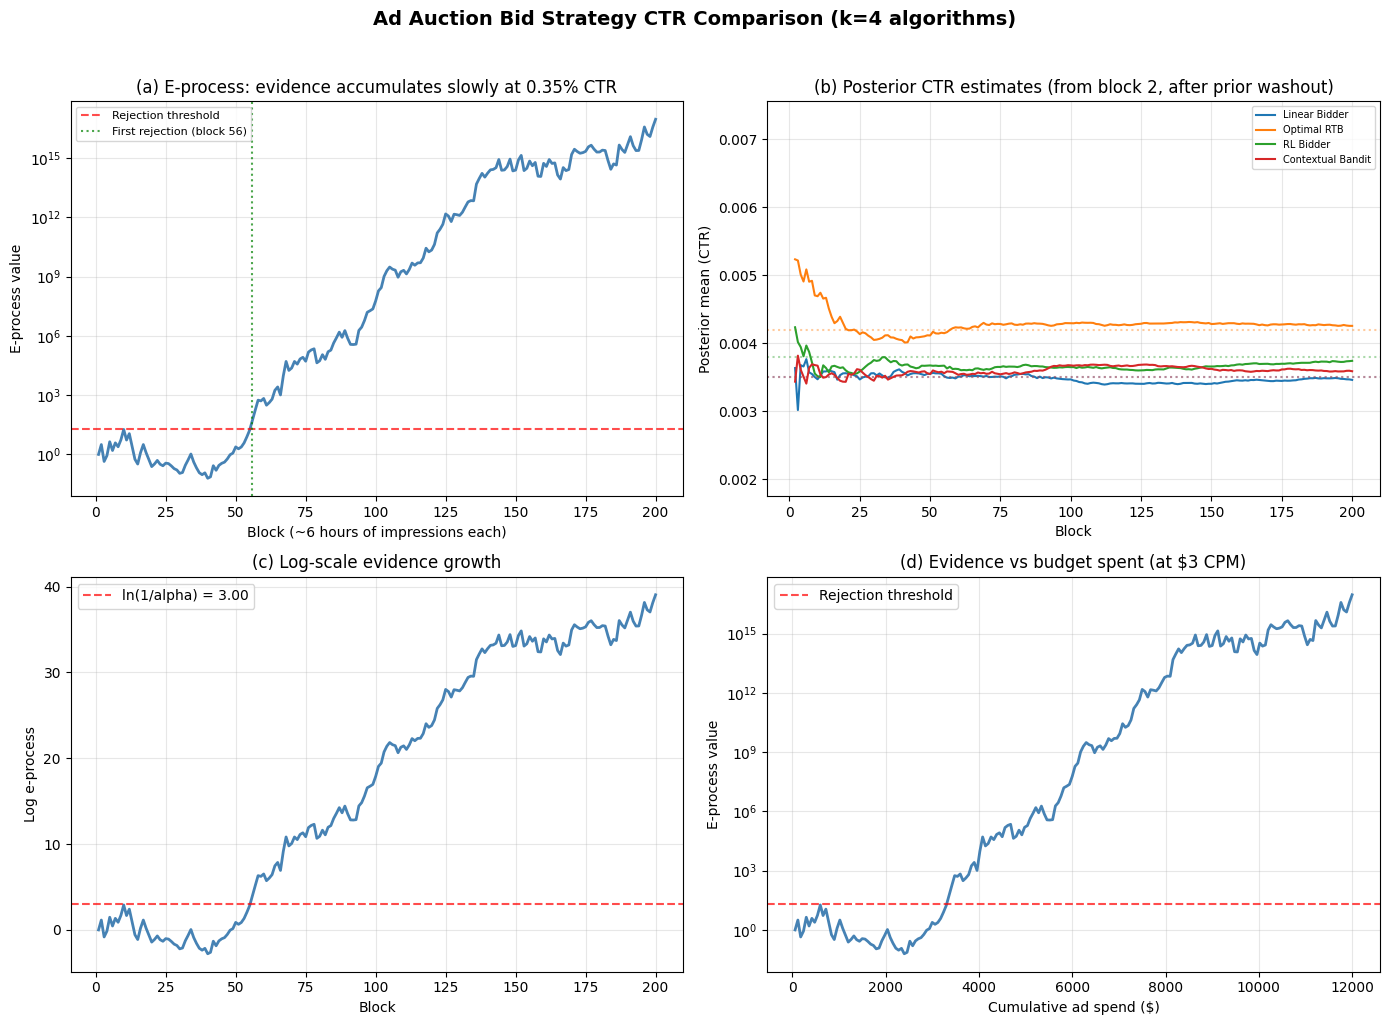


Key takeaway:
  At very low base rates (0.35% CTR), evidence accumulates gradually.
  The Beta(0.18, 0.18) prior starts at 0.5 and must converge to ~0.004
  before meaningful discrimination begins. This is realistic for display
  advertising -- but sequential testing still saves significant time vs
  a fixed-horizon design that commits to a sample size upfront.


In [ ]:
# Visualization: auction algorithm comparison
df_auction = test_auction.get_history_df()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) E-process evolution (slow accumulation due to low CTR)
ax = axes[0, 0]
ax.plot(df_auction['step'], df_auction['e_process_value'], linewidth=2, color='steelblue')
ax.axhline(20, color='red', linestyle='--', alpha=0.7, label='Rejection threshold')
if stop_block_auction:
    ax.axvline(stop_block_auction, color='green', linestyle=':', alpha=0.7,
               label=f'First rejection (block {stop_block_auction})')
ax.set_xlabel('Block (~6 hours of impressions each)')
ax.set_ylabel('E-process value')
ax.set_title('(a) E-process: evidence accumulates slowly at 0.35% CTR')
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (b) Posterior theta estimates convergin
ax = axes[0, 1]
algo_names = ['Linear Bidder', 'Optimal RTB', 'RL Bidder', 'Contextual Bandit']
df_zoom = df_auction[df_auction['step'] >= 2]
for g in range(4):
    ax.plot(df_zoom['step'], df_zoom[f'theta_{g}'], label=algo_names[g], linewidth=1.5)
    ax.axhline(true_ctr[g], color=f'C{g}', linestyle=':', alpha=0.4)
ax.set_xlabel('Block')
ax.set_ylabel('Posterior mean (CTR)')
ax.set_title('(b) Posterior CTR estimates (from block 2, after prior washout)')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

all_ctr_values = [true_ctr[g] for g in range(4)]
y_lo = min(all_ctr_values) * 0.5
y_hi = max(all_ctr_values) * 1.8
ax.set_ylim(y_lo, y_hi)

# (c) Log e-process to show gradual evidence
ax = axes[1, 0]
ax.plot(df_auction['step'], df_auction['log_e_process'], linewidth=2, color='steelblue')
ax.axhline(np.log(20), color='red', linestyle='--', alpha=0.7,
           label=f'ln(1/alpha) = {np.log(20):.2f}')
ax.set_xlabel('Block')
ax.set_ylabel('Log e-process')
ax.set_title('(c) Log-scale evidence growth')
ax.legend()
ax.grid(True, alpha=0.3)

# (d) Cumulative impressions vs evidence, the business tradeoff
total_impressions = df_auction['step'] * block_size_auction * 4
cpm = 3.0  # $3 CPM
ad_spend = total_impressions * cpm / 1000
ax = axes[1, 1]
ax.plot(ad_spend, df_auction['e_process_value'], linewidth=2, color='steelblue')
ax.axhline(20, color='red', linestyle='--', alpha=0.7, label='Rejection threshold')
ax.set_xlabel('Cumulative ad spend ($)')
ax.set_ylabel('E-process value')
ax.set_title('(d) Evidence vs budget spent (at $3 CPM)')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Ad Auction Bid Strategy CTR Comparison (k=4 algorithms)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nKey takeaway:")
print("  At very low base rates (0.35% CTR), evidence accumulates gradually.")
print("  The Beta(0.18, 0.18) prior starts at 0.5 and must converge to ~0.004")
print("  before meaningful discrimination begins. This is realistic for display")
print("  advertising - but sequential testing still saves significant time vs")
print("  a fixed-horizon design that commits to a sample size upfront.")

# 11. How It Works: The RIPr Construction

The Bernoulli k-sample e-variable is based on the **RIPr** (Reverse Information
Projection) framework from Turner, Ly & Grunwald (2022).

**Key idea:** At each step j, the e-variable is a likelihood ratio:

$$S_j = \prod_{g=1}^{k} \frac{\theta_g^{s_g} (1-\theta_g)^{n_g - s_g}}{\theta_0^{s_g} (1-\theta_0)^{n_g - s_g}}$$

where:
- $\theta_g$ = per-group estimate under the alternative (Beta posterior mean)
- $\theta_0 = \sum_g \frac{n_g}{n} \theta_g$ = RIPr projection onto H0
- $s_g$ = successes in group g for this block
- $n_g$ = observations in group g for this block

**Critical property:** $\theta_g$ is computed from data **before** this block
($\mathcal{F}_{j-1}$-measurable), making $S_j$ an exact e-variable
(not just approximately valid).

**Three alternative types:**

| Alternative | $\theta_g$ source | Reference |
|---|---|---|
| Unrestricted | Beta($\gamma$,$\gamma$) posterior mean per group | Proposition 2 |
| Effect-size restricted | Grid-based discretized posterior (k=2 only) | Appendix S1 |
| Simple | Fixed user-specified values | Eq. 3.2 |

**Temporal combination:** Per-step e-values $S_1, S_2, \ldots$ are combined
into an e-process $M_j$ using a betting strategy (Chapter 7, Ramdas & Wang 2025).
Rejection at level $\alpha$ when $\max_{j \leq t} M_j \geq 1/\alpha$ (Ville's inequality).